# BERT 만들기

vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 봅니다.


## 0. 환경 준비

드라이브를 연결하고, 코퍼스(kowiki.txt)를 내려받습니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/Aiffel_EPA/bert_pretrain'
DATA_DIR  = f'{BASE_DIR}/data'
MODEL_DIR = f'{BASE_DIR}/models'

!mkdir -p "{DATA_DIR}" "{MODEL_DIR}"
!wget -nc https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -P "{DATA_DIR}"
!unzip -n "{DATA_DIR}/kowiki.txt.zip" -d "{DATA_DIR}"
!ls -l "{DATA_DIR}"


Mounted at /content/drive
File ‘/content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip’ already there; not retrieving.

Archive:  /content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip
total 2446795
-rw------- 1 root root  154611145 Sep 16 06:03 bert_pre_train_8000.json
-rw------- 1 root root 1354966647 Sep 16 03:46 bert_pre_train.json
-rw------- 1 root root   86270165 Sep 16 06:03 kowiki_sub.txt
-rw------- 1 root root  666544979 Jul 11  2020 kowiki.txt
-rw------- 1 root root  243123354 Jun 23  2021 kowiki.txt.zip


In [2]:
!pip install -q sentencepiece tqdm


In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

print(torch.__version__)

# GPU 런타임이면 cuda 가 잡혀야 학습 속도가 빠름 (런타임 유형을 GPU 로 설정했는지 확인)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


2.11.0+cu128
device: cuda


## 1. Tokenizer 준비 (vocab_size = 8000)

`kowiki.txt` 전체를 그대로 사용해 SentencePiece 모델을 학습합니다.
 `vocab_size` 8000 으로 설정합니다.


In [4]:
# [변경] vocab_size 를 32000 -> 8000 으로 축소 (과제 요구사항)
# +7 은 예약 토큰 4개([PAD],[UNK],[BOS],[EOS]) + 사용자 정의 토큰 3개([SEP],[CLS],[MASK])
# 자리를 미리 확보해두는 것. 이 7개를 안 더하면 vocab_size 예산 안에서 서브워드 자리가 7개만큼 부족해짐.
corpus_file = f'{DATA_DIR}/kowiki.txt'
prefix = f'{MODEL_DIR}/ko_8000'
vocab_size = 8000

if not os.path.exists(f'{prefix}.model'):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}"
        " --model_type=bpe --max_sentence_length=999999"
        " --input_sentence_size=1000000 --shuffle_input_sentence=true"
        " --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK]"
        " --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS]"
        " --user_defined_symbols=[SEP],[CLS],[MASK]")
print(os.listdir(MODEL_DIR))


['ko_32000.model', 'ko_32000.vocab', 'bert_pre_train_epoch_1.pt', 'bert_pre_train_epoch_2.pt', 'ko_8000.model', 'ko_8000.vocab', 'mini_bert_epoch_1.pt', 'mini_bert_epoch_2.pt', 'mini_bert_epoch_3.pt', 'mini_bert_epoch_4.pt', 'mini_bert_epoch_5.pt', 'mini_bert_epoch_6.pt', 'mini_bert_epoch_7.pt', 'mini_bert_epoch_8.pt', 'mini_bert_epoch_9.pt', 'mini_bert_epoch_10.pt']


In [5]:
# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{MODEL_DIR}/ko_8000.model")

print("vocab size (특수토큰 7개 포함):", len(vocab))

# 특수 token 7개를 제외한 나머지 token 목록 (뒤에서 MLM의 '무작위 토큰으로 치환'에 사용됨)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print("일반 서브워드 개수:", len(vocab_list))

# 토크나이저 동작 확인
sample = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
print(vocab.encode_as_pieces(sample))


vocab size (특수토큰 7개 포함): 8007
일반 서브워드 개수: 8000
['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아']


## 2. 데이터 전처리 (1) MASK 생성

전체 토큰의 15%를 **띄어쓰기(단어) 단위**로 묶어서 마스킹 후보로 고릅니다. 서브워드 하나씩 따로
가리면 앞뒤 글자 패턴만 보고 요행으로 맞힐 수 있어서, 반드시 단어 전체를 한 덩어리로 가려야 합니다.
마스킹 대상으로 뽑힌 단어마다 주사위를 무작위로 굴려 80%는 `[MASK]`, 10%는 원래 토큰 유지, 10%는
무작위 토큰으로 바꿉니다 (모델이 `[MASK]` 자리만 보고 나머지 문맥을 대충 처리하는 것을 막기 위함).


In [6]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어(띄어쓰기) 단위로 마스킹하기 위해, 서브워드 시작 마커(U+2581, '▁')를 기준으로 index 를 묶음
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"▁"):
            cand_idx[-1].append(i)  # 앞 단어의 연속 서브워드면 같은 그룹에 추가
        else:
            cand_idx.append([i])    # 새 단어의 시작이면 새 그룹 생성

    # 무작위로 어떤 단어부터 마스킹할지 순서를 섞음
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:       # 이미 15% 채웠으면 종료
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 이 단어를 넣으면 15%를 초과하면 skip
            continue
        dice = random.random()              # 이 "단어" 전체에 대해 주사위 1번만 굴림
        for index in index_set:
            masked_token = None
            if dice < 0.8:                  # 80%: [MASK] 로 치환
                masked_token = "[MASK]"
            elif dice < 0.9:                 # 10%: 원래 토큰 유지
                masked_token = tokens[index]
            else:                             # 10%: 무작위 토큰으로 치환
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})  # 정답(원래 토큰)을 기억해둠
            tokens[index] = masked_token

    # 위치 순서대로 정렬해 mask_idx / mask_label 로 분리
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

print("슝=3")


슝=3


## 3. 데이터 전처리 (2) NSP pair 생성

연속된 두 문장을 이어붙여 `[CLS] A [SEP] B [SEP]` 형태로 만들고, 50% 확률로 A/B 순서를 뒤바꿔서
"진짜로 이어지는 순서인가(`is_next`)"를 라벨로 답니다.

길이가 넘치면 `[SEP]` 경계에서 먼 쪽(A의 맨 앞, B의 맨 뒤)부터 잘라내 경계 정보를 최대한 보존합니다.
segment는 A 구간을 0, B 구간을 1로 채웁니다.


In [7]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이 합이 max_seq 를 넘지 않을 때까지 줄임.
    [SEP] 에 붙어있는 경계(=NSP 판단에 가장 중요한 정보)는 최대한 보존하기 위해,
    A는 맨 앞에서, B는 맨 뒤에서 잘라낸다 (경계에서 먼 쪽부터 제거).
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]      # A는 맨 앞을 제거
        else:
            tokens_b.pop()       # B는 맨 뒤를 제거


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    문서(doc, 줄 단위 토큰 리스트) 하나로부터 NSP+MLM 학습 인스턴스들을 생성
    :param doc: 한 문서를 줄 단위로 토크나이즈한 리스트
    :param n_seq: [CLS], A, [SEP], B, [SEP] 를 합친 최대 길이
    :param mask_prob: 마스킹 비율 (0.15)
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 세 자리를 미리 빼둠

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        # 길이가 max_seq 이상 쌓였거나 문서의 마지막 줄이면, 지금까지 모은 줄들로 A/B 쌍을 하나 만듦
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))  # 어디까지를 A로 할지 무작위 결정
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:   # 50% 확률로 A/B 순서를 뒤바꿔 NotNext 예시를 만듦
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # [CLS] A [SEP] B [SEP] 형태로 결합, segment 는 A=0, B=1 (SEP 는 각 구간에 포함)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # MLM 마스킹까지 이 단계에서 함께 적용 (BERT는 NSP+MLM을 같은 입력으로 동시에 학습하므로)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            })

            current_chunk = []
            current_length = 0
    return instances

print("슝=3")


슝=3


## 4. 데이터 전처리 (3) 데이터셋 완성

코퍼스(약 400만 줄) 전체를 문단(빈 줄 기준) 단위로 읽어 `create_pretrain_instances()`를 적용하고,
결과를 json 파일로 저장합니다. 이후 `np.memmap`으로 로딩해 메모리 사용량을 최소화합니다.

In [8]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):    # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))
    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":               # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):                  # 파일 끝에 처리 안 된 문서가 남아있으면 마저 처리
                save_pretrain_instances(out_f, doc)

pretrain_json_path = f'{DATA_DIR}/bert_pre_train_8000.json'
N_SEQ = 128  # [CLS] A [SEP] B [SEP] 를 합친 시퀀스 최대 길이 (강의와 동일)

make_pretrain_data(vocab, corpus_file, pretrain_json_path, N_SEQ)

total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
print("생성된 instance 수:", total)


  0%|          | 0/3957761 [00:00<?, ?it/s]

생성된 instance 수: 916606


In [9]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir='/content/memmap'):
    """
    json 데이터셋을 np.memmap 으로 로딩 (전체를 한 번에 메모리에 올리지 않기 위함)
    :param count: 로딩할 데이터 수 제한 (None 이면 전체)
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    os.makedirs(memmap_dir, exist_ok=True)
    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=f'{memmap_dir}/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                break
            data = json.loads(line)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))   # 남는 자리는 [PAD](id=0) 로 채움

            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            label_nsp = data["is_next"]

            # MLM 라벨: 전부 0([PAD] id) 으로 채운 뒤, 마스킹된 자리에만 정답 id 를 심음
            # -> 이후 학습 때 CrossEntropyLoss(ignore_index=0) 과 짝을 이뤄, 마스킹 안 된 자리는
            #    손실 계산에서 자동으로 제외되도록 설계된 것
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

# 생성된 instance 를 전부 메모리(memmap)에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, N_SEQ)

print("enc_tokens shape:", pre_train_inputs[0].shape)
print("segments   shape:", pre_train_inputs[1].shape)


  0%|          | 0/916606 [00:00<?, ?it/s]

enc_tokens shape: (916606, 128)
segments   shape: (916606, 128)


## 5. BERT 모델 구현

config 값을 mini 버전(파라미터 약 1M)으로 지정합니다.


In [10]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad([PAD]) 토큰 위치를 찾아 attention 이 그 자리를 무시하도록 만드는 마스크
    :return mask: pad 인 자리는 1, 아닌 자리는 0  (shape: (bs, 1, n_seq))
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    미래 토큰까지 가리는 마스크 (causal mask). GPT 같은 decoder-only 모델에 필요한 함수이며,
    BERT는 진짜 양방향(bidirectional) Encoder 구조라 forward 에서 이 함수를 호출하지 않는다.
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

def gelu(x):
    """ GELU activation (tanh 근사식). ReLU 대신 사용 (BERT 논문 방식) """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class Config(dict):
    """ dict 를 config.attr 형태로 접근할 수 있게 해주는 래퍼 클래스 """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            return Config(json.loads(f.read()))

print("슝=3")


슝=3


In [11]:
class SharedEmbedding(nn.Module):
    """
    입력 토큰 임베딩(lookup)과 MLM 출력층(vocab 크기로의 선형변환)이 같은 가중치를 공유(weight tying)하는 레이어.
    mode="embedding" 이면 룩업 테이블처럼, mode="linear" 이면 출력층(분류기)처럼 동작한다.
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
            # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
            # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        # 토큰 id를 그대로 인덱스로 써서 임베딩 테이블에서 행을 꺼내옴
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)

        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs


class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        # cumsum으로 각 토큰의 위치 인덱스(0,1,2,...)를 만들어 그 인덱스로 임베딩을 조회
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")


슝=3


In [12]:
class ScaleDotProductAttention(nn.Module):
    """ Q,K 의 내적으로 관련도를 계산하고, 그 가중치로 V 를 가중합하는 attention 의 핵심 연산 """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        # d_head가 커질수록 내적값이 커져 softmax가 한쪽으로 쏠리는 걸 막기 위해 sqrt(d_head)로 스케일링
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        # mask 가 1인 자리(PAD 등)는 아주 큰 값을 빼서 softmax 후 확률이 0에 가깝도록 만듦
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """   Multi Head Attention Class  """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)  # head 축으로 broadcast 되도록 차원 추가

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)

        return attn_out


class PositionWiseFeedForward(nn.Module):
    """ 각 위치(토큰)마다 독립적으로 적용되는 2층 신경망 (확장 -> GELU -> 축소) """
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    """ Encoder Layer Class """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        # residual connection: attention 결과만 쓰지 않고 원래 입력을 더해 층이 깊어져도 정보/그래디언트가 보존되게 함
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")


슝=3


In [13]:
class BERT(nn.Module):
    def __init__(self, config):
        super(BERT, self).__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)   # 문장 A/B 를 구분 (0 또는 1 이므로 간단히 처리)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)   # BERT는 ahead mask 없이 pad mask만 사용 (양방향)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]                       # [CLS] 위치(index 0) 벡터 -> NSP 예측용
        logits_lm = self.embedding(enc_out, mode="linear")  # weight tying 된 출력층 -> MLM 예측용
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        # 토큰 + 위치 + 세그먼트 임베딩을 더한 뒤 LayerNorm 으로 분포를 정리
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


class PooledOutput(nn.Module):
    """ NSP 분류 헤드: [CLS] 벡터 -> dense+tanh -> dense(2-class) """
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    """ 최종 pretrain 모델 """
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")


슝=3


In [14]:
# [변경] 전체 파라미터가 약 1M 이 되도록 축소한 mini BERT config
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "d_ff": 192,
    "n_layer": 3,
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_seq": N_SEQ,
    "n_vocab": len(vocab),      # 8007 = 8000(서브워드) + 7(특수토큰) — 직접 적지 않고 토크나이저에서 읽어옴
    "i_pad": vocab.pad_id(),    # 0
})

pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

n_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"총 파라미터 수: {n_params:,}  (목표: 약 1,000,000)")
print(pre_train_model)


총 파라미터 수: 1,015,200  (목표: 약 1,000,000)
PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 96)
    )
    (segment): Embedding(2, 96)
    (norm): LayerNorm((96,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=96, out_features=96, bias=True)
          (W_K): Linear(in_features=96, out_features=96, bias=True)
          (W_V): Linear(in_features=96, out_features=96, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=96, out_features=96, bias=True)
        )
        (norm1): LayerNorm((96,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=96, out_features=192, bias=True)
          (W_2): Linear(in_features=192, out_features=96, bias=True)
          (gelu): GELU(appro

## 6. pretrain 진행

Learning Rate 는 강의와 동일하게 warmup(선형 증가) 후 cosine 곡선으로 감소시킵니다. 손실 함수는
NSP·MLM 각각 `CrossEntropyLoss`를 쓰되, MLM 쪽만 `ignore_index=0`을 걸어 마스킹 안 된 자리(라벨 0)를
손실 계산에서 자동으로 제외합니다. **10 epoch** 학습하고, 검증(validation)/early stopping 은 추가하지
않고 기본 형태로 진행합니다.


In [15]:
class CosineSchedule:
    """ warmup 구간 동안 lr 을 선형으로 올리고, 이후 cosine 곡선을 따라 서서히 0까지 낮추는 스케줄러 """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr

print("슝=3")


슝=3


In [16]:
# [변경] epoch=10, batch_size는 미니 데이터셋 크기에 맞춰 설정
EPOCHS = 10
BATCH_SIZE = 64

pre_train_inputs_t = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels_t = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs_t[0], pre_train_inputs_t[1],
                               pre_train_labels_t[0], pre_train_labels_t[1])
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

train_steps = math.ceil(len(pre_train_inputs[0]) / BATCH_SIZE) * EPOCHS
print("총 학습 step 수:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)  # lr 은 매 step CosineSchedule 이 결정
learning_rate_scheduler = CosineSchedule(
    optimizer, train_steps=train_steps, warmup_steps=max(100, train_steps // 10), max_lr=2.5e-4)

loss_fn_nsp = nn.CrossEntropyLoss()                 # NSP: 예시당 라벨이 1개뿐이라 제외할 자리가 없음
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)   # MLM: 라벨 0(=마스킹 안 된 자리)은 손실 계산에서 제외


총 학습 step 수: 143220


In [17]:
history = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

for epoch in range(EPOCHS):
    pre_train_model.train()
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        # logits_mlm: (bs, n_seq, n_vocab) -> (bs*n_seq, n_vocab) 로 펼쳐서 CrossEntropyLoss 에 전달
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        loss = loss_nsp + loss_mlm     # 두 과제(NSP+MLM)를 동시에 학습 (loss를 단순히 더함)
        loss.backward()
        optimizer.step()
        learning_rate_scheduler.step()   # step(배치) 단위로 학습률 갱신

        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # NSP 정확도: 예시 전체가 채점 대상이므로 단순 평균
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        # MLM 정확도: 마스킹된 자리(labels_mlm_batch != 0)만 채점 대상 (loss와 동일한 논리)
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / \
                  mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    n_batches = len(train_dataloader)
    history['nsp_loss'].append(total_nsp_loss / n_batches)
    history['mlm_loss'].append(total_mlm_loss / n_batches)
    history['nsp_acc'].append(total_nsp_acc / n_batches)
    history['mlm_acc'].append(total_mlm_acc / n_batches)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"NSP Loss: {history['nsp_loss'][-1]:.4f} | MLM Loss: {history['mlm_loss'][-1]:.4f} | "
          f"NSP Acc: {history['nsp_acc'][-1]:.4f} | MLM Acc: {history['mlm_acc'][-1]:.4f}")

    # 에폭마다 모델 가중치 저장 (중간에 세션이 끊겨도 이어서 확인 가능하도록)
    torch.save(pre_train_model.state_dict(), f"{MODEL_DIR}/mini_bert_epoch_{epoch+1}.pt")


Epoch 1/10:   0%|          | 0/14322 [00:00<?, ?it/s]

Epoch 1/10 | NSP Loss: 0.4756 | MLM Loss: 7.5603 | NSP Acc: 0.7030 | MLM Acc: 0.0294


Epoch 2/10:   0%|          | 0/14322 [00:00<?, ?it/s]

Epoch 2/10 | NSP Loss: 0.3878 | MLM Loss: 6.6654 | NSP Acc: 0.7576 | MLM Acc: 0.0830


Epoch 3/10:   0%|          | 0/14322 [00:00<?, ?it/s]

...

Epoch 8/10 | NSP Loss: 0.3539 | MLM Loss: 4.7096 | NSP Acc: 0.7727 | MLM Acc: 0.2379


Epoch 9/10:   0%|          | 0/14322 [00:00<?, ?it/s]

Epoch 9/10 | NSP Loss: 0.3524 | MLM Loss: 4.6887 | NSP Acc: 0.7740 | MLM Acc: 0.2399


Epoch 10/10:   0%|          | 0/14322 [00:00<?, ?it/s]

Epoch 10/10 | NSP Loss: 0.3517 | MLM Loss: 4.6803 | NSP Acc: 0.7750 | MLM Acc: 0.2405


## 6-1. 학습된 모델로 NSP 확인

두 문장 A, B를 직접 넣어서, 학습된 모델이 "B가 A의 다음 문장으로 자연스러운지(IsNext)" 확률을
어떻게 예측하는지 확인합니다.


In [25]:
def predict_nsp(sent_a, sent_b, model, vocab, n_seq=128):
    model.eval()

    tokens_a = vocab.encode_as_pieces(sent_a)
    tokens_b = vocab.encode_as_pieces(sent_b)

    max_seq = n_seq - 3
    tokens_a, tokens_b = tokens_a.copy(), tokens_b.copy()
    trim_tokens(tokens_a, tokens_b, max_seq)

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    enc_token = [vocab.piece_to_id(p) for p in tokens]
    enc_token += [0] * (n_seq - len(enc_token))
    segment += [0] * (n_seq - len(segment))

    enc_token_t = torch.tensor([enc_token], dtype=torch.long, device=device)
    segment_t = torch.tensor([segment], dtype=torch.long, device=device)

    with torch.no_grad():
        logits_nsp, _ = model(enc_token_t, segment_t)

    probs = F.softmax(logits_nsp, dim=-1)
    return probs[0, 1].item()


def print_nsp_result(sent_a, sent_b):
    prob = predict_nsp(sent_a, sent_b, pre_train_model, vocab)
    print(f"문장 A: {sent_a}")
    print(f"문장 B: {sent_b}")
    print(f"👉 두 문장이 자연스럽게 이어질 확률 (IsNext): {prob * 100:.2f}%")
    print()

print_nsp_result("오늘 날씨가 매우 좋습니다.", "그래서 기분이 좋습니다.")
print_nsp_result("오늘 날씨가 매우 좋습니다.", "시험 성적이 낮게 나왔다.")


문장 A: 오늘 날씨가 매우 좋습니다.
문장 B: 그래서 기분이 좋습니다.
👉 두 문장이 자연스럽게 이어질 확률 (IsNext): 48.66%

문장 A: 오늘 날씨가 매우 좋습니다.
문장 B: 시험 성적이 낮게 나왔다.
👉 두 문장이 자연스럽게 이어질 확률 (IsNext): 48.12%



## 7. 프로젝트 결과

학습 곡선을 시각화하고, NSP/MLM 이 수렴하는 경향을 확인합니다.

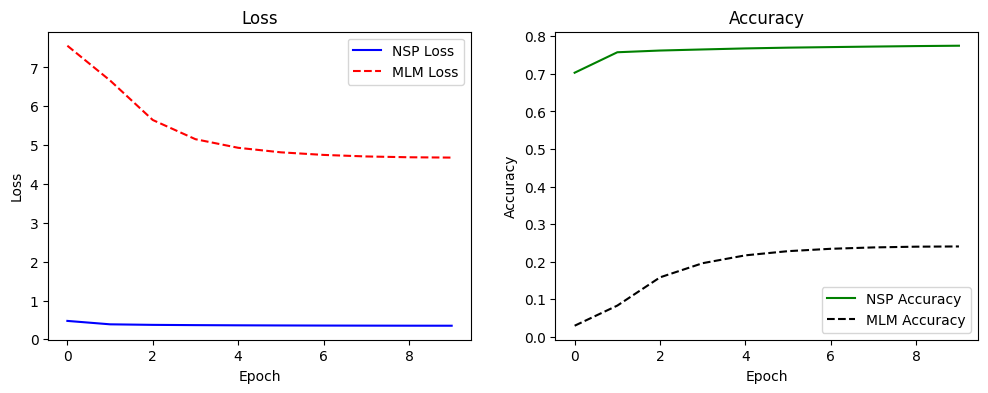

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()


## 회고

- **최종 결과**: NSP Loss (0.3517) / MLM Loss (4.6803), NSP Acc (0.7750) / MLM Acc (0.2405)
- **수렴 여부**: *위 그래프에서 loss가 epoch가 지날수록 계속 떨어졌다.8 epoch 부턴 거의 수렴했다. Accuracy도 8epoch 부턴 수렴했다.
- **모델 크기·학습 시간의 관계**: 이번 mini BERT는 파라미터 약 1M(정식 BERT의 약 1/300 수준)로, vocab_size·코퍼스·모델 크기를 모두 강의안 대비 크게 줄여 짧은 시간 안에 학습을 마칠 수 있었다. 다만 모델과 데이터가 작아진 만큼 실제 언어 이해 성능은 정식 BERT에 크게 못 미친 것 같다.
- **아쉬운 점**:
정성적 평가 기준으로 결과가 많이 아쉬웠다. 자연스러운 문장을 줘도 자연스럽게 이어질 확률을 너무 낮게 나왔고, 반대로 자연스럽지 않은 문장인데도 자연스럽게 평가하는 확률이 너무 높았다. 또한 epoch 한 번에 너무 오래(10분)걸리다 보니 다양한 시도를 할 시간이 없었다.
- **다음에 시도해보고 싶은 것** 이를 개선하기 위해 validation 세트를 분리해 과적합 여부를 확인해보거나, 코퍼스를 더 늘려서 재학습해보고 싶다. 하지만 이번엔 시간이 부족하여 진행하지 못했다.
